In [861]:
import pandas as pd
import numpy as np
df = pd.read_parquet("../data/processed/cleaned_2021_customer_data.parquet").drop(columns="future_spend")

### The time period for the data used here is 1 year (2021)

In [862]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36086 entries, 0 to 36085
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           36086 non-null  int64         
 1   transaction_count     36086 non-null  int64         
 2   promo_usage_count     36086 non-null  int64         
 3   quantity              36086 non-null  int64         
 4   avg_order_value       36086 non-null  float64       
 5   first_purchase_date   36086 non-null  datetime64[ns]
 6   last_purchase_date    36086 non-null  datetime64[ns]
 7   purchase_recency      36086 non-null  float64       
 8   customer_tenure       36086 non-null  float64       
 9   payment_method_count  36086 non-null  int64         
 10  total_spent           36086 non-null  float64       
dtypes: datetime64[ns](2), float64(4), int64(5)
memory usage: 3.0 MB


In [863]:
df["total_spent"].sum()

25577540.15

__We made over $25.5 million in 2021__

### Revenue Distribution

In [864]:
# How much our various customer distribution made

df_sorted = df.sort_values('total_spent', ascending=False).reset_index(drop=True)

df_sorted['cum_revenue'] = df_sorted['total_spent'].cumsum()
df_sorted['cum_revenue_pct'] = (
    df_sorted['cum_revenue'] / df_sorted['total_spent'].sum()
) * 100

# Cumulative customer percentage
df_sorted['cum_customer_pct'] = (
    (df_sorted.index + 1) / len(df_sorted)
) * 100

print("Based on Total Spent alone:")
for p in [5, 10, 20, 30, 50]:
    revenue_share = df_sorted.loc[
        df_sorted['cum_customer_pct'] <= p, 
        'total_spent'
    ].sum() / df['total_spent'].sum() * 100
    
    print(f"Top {p}% customers generate {revenue_share:.2f}% of revenue")

Based on Total Spent alone:
Top 5% customers generate 46.30% of revenue
Top 10% customers generate 63.93% of revenue
Top 20% customers generate 81.55% of revenue
Top 30% customers generate 89.90% of revenue
Top 50% customers generate 96.87% of revenue


<hr/>

# RFM Segmentation

Assigning scores based on different values of RFM (e.g 5-5-5 means high recency, high frequency and total monetary value)

In [865]:
RFM = df[["customer_id", "purchase_recency", "transaction_count", "total_spent",
           "customer_tenure", "quantity", "avg_order_value"]].copy()

## 1. Recency Score (1-5)

The lower the `purchase_recency`, the higher the recency score. (Top 20% lowest have a score of 5)

In [866]:
RFM["recency_score"] = pd.qcut(RFM["purchase_recency"], q=5, labels=[5, 4, 3, 2, 1])

recency_bins = RFM.groupby('recency_score', observed=True)['purchase_recency'].agg(['min', 'max']).sort_index(ascending=False)

print("Score Ranges:")
print(recency_bins)

Score Ranges:
                      min         max
recency_score                        
1              129.582811  364.948454
2               54.738876  129.577530
3               25.127685   54.735412
4                9.787500   25.126849
5                0.000191    9.786073


## 2. Frequency Score

Shows how often they make a purchase

25% of customers only made one purchase in the time period

In [867]:
RFM['frequency_score'] = pd.qcut(RFM['transaction_count'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

frequency_bins = RFM.groupby('frequency_score', observed=True)['transaction_count'].agg(['min', 'max']).sort_index(ascending=False)

print("Score Ranges:")
print(frequency_bins)

Score Ranges:
                 min  max
frequency_score          
5                 10  160
4                  5   10
3                  2    5
2                  1    2
1                  1    1


## 3. Monetary Score

Customers are given scores based on how much they have spent

In [868]:
RFM["monetary_score"] = pd.qcut(RFM["total_spent"], q=5, labels=[1, 2, 3, 4, 5])

monetary_bins = RFM.groupby('monetary_score', observed=True)['total_spent'].agg(['min', 'max']).sort_index(ascending=False)

print("Score Ranges:")
print(monetary_bins)

Score Ranges:
                    min        max
monetary_score                    
5               819.485  52428.261
4               233.454    819.397
3                75.413    233.440
2                25.305     75.369
1                 1.635     25.303


<hr/>

## Segment Labelling

We'll come up with customer label groups based on the different RFM scores. Setting RFM values for segments is what really is responsible for separating our customers and personalizing retention efforts

In [869]:
RFM["recency_score"] = RFM["recency_score"].astype(int)
RFM["frequency_score"] = RFM["frequency_score"].astype(int)
RFM["monetary_score"] = RFM["monetary_score"].astype(int)

r, f, m = RFM["recency_score"], RFM["frequency_score"], RFM["monetary_score"]

RFM["segment_label"] = np.select(
    [
        (r >= 4) & (f >= 4) & (m == 5),     # Champions ->  Recent, frequent, top spenders — your best customers, driving the most revenue
        (r >= 4) & (f >= 3) & (m >= 5),     # Loyal High Value ->   Consistently active, high spend — reliable core customers with strong retention
        (r <= 2) & (f <= 3) & (m >= 4),     # Lost High Value ->    Once high-spend but haven't returned — high ROI target for win-back campaigns
        (r >= 4) & (f <= 2),                # New / One-time -> Bought recently but only once or twice — need nurturing to become repeat buyers
        (r >= 3) & (f >= 4) & (m >= 4),     # Potential Loyalists -> Strong RFM profile but not quite Champions yet — close to tipping into loyal
        (r <= 2) & (f >= 4) & (m >= 4),     # At-Risk High Value -> Previously loyal and high-value but going cold — urgent churn prevention targets
        (r <= 2) & (f >= 3) & (m >= 3),     # Needs Attention ->   Decent history but fading — haven't bought recently, at risk of being lost
        (r >= 3) & (f >= 3) & (m >= 3),     # Engaged Mid-Value ->  Active and consistent but moderate spend — stable base, worth incremental growth
        (r >= 3) & (f <= 2) & (m >= 3),     # Occasional Spenders ->  Buys infrequently but spend decently when they do — activation candidates
        (r <= 2) & (f <= 2) & (m <= 2),     # Low Activity / Low Value ->   Low across all dimensions — minimal engagement and spend, low priority
        (RFM["transaction_count"] == 1)     # one-time buyers -> Includes older and newer customers, regardless of how much the spent
    ],
    [
        "Champions",
        "Loyal High Value",
        "Lost High Value",
        "New / One-time",
        "Potential Loyalists",
        "At-Risk High Value",
        "Needs Attention",
        "Engaged Mid-Value",
        "Occasional Spenders",
        "Low Activity / Low Value",
        "One-timers"
    ],
    default="Regulars"   # Mixed or average profile that doesn't fit a clear pattern, monitor for movement
)


In [870]:
# Grouping segments by revenue and customers percentage
segment_revenue = RFM.groupby('segment_label')['total_spent'].sum()
segment_customers = RFM.groupby('segment_label')['customer_id'].count()

revenue_percentage = (segment_revenue / segment_revenue.sum()) * 100
customers_percentage = (segment_customers / segment_customers.sum()) * 100

revenue_summary = pd.DataFrame({
    'Total Revenue': segment_revenue,
    'Revenue(%)': revenue_percentage,
    'Customers(%)' : customers_percentage,
    'Customers': segment_customers,
}).sort_values(by='Revenue(%)', ascending=False).reset_index()

revenue_summary['Revenue(%)'] = revenue_summary['Revenue(%)'].round(2)
revenue_summary['Customers(%)'] = revenue_summary['Customers(%)'].round(2)


print(revenue_summary)

               segment_label  Total Revenue  Revenue(%)  Customers(%)  \
0                  Champions   1.634955e+07       63.92         14.90   
1        Potential Loyalists   4.067351e+06       15.90         15.98   
2            Lost High Value   1.819551e+06        7.11          4.56   
3          Engaged Mid-Value   1.401353e+06        5.48         14.77   
4           Loyal High Value   5.155400e+05        2.02          0.62   
5        Occasional Spenders   3.587378e+05        1.40          1.66   
6                   Regulars   2.673685e+05        1.05         12.87   
7   Low Activity / Low Value   2.225062e+05        0.87         25.82   
8         At-Risk High Value   1.910803e+05        0.75          0.44   
9             New / One-time   1.441382e+05        0.56          2.05   
10           Needs Attention   1.367771e+05        0.53          2.89   
11                One-timers   1.035858e+05        0.40          3.44   

    Customers  
0        5377  
1        5765  
2 

One-timers, which made up 25% of transactions, contribute only a small amount of overall revenue gain

<hr/>

Now we have a comprehensive list of different customer groups based on how much they have spent. It's clear just how important __Champions__ category is, with only __14.9% of them making up 63.9%(about $16.3m)__ of the $25.5 million that was made in 2021 making each worth an average of __$3,040__.

Retention of champions always matters the most

<hr/>

We can basically group our customers into as man segments as necessary. We can craft highly personalized retention campaigns tailored to different segments. 

With yearly revenue of about $25.5 million, Let's break down some math:

### Average Revenue Per Customer

| Segment | Customers | Total Revenue | Avg Rev / Customer |
|---|---|---|---|
| Champions | 5,377 | $16,349,550 | **$3,041** |
| Loyal High Value | 4,460 | $2,527,127 | **$567** |
| Potential Loyalists | 1,917 | $2,223,357 | **$1,160** |
| Lost High Value | 1,645 | $1,819,551 | **$1,106** |
| Engaged Mid-Value | 4,941 | $1,233,759 | **$250** |
| At-Risk High Value | 157 | $191,080 | **$1,217** |
| New / One-time | 741 | $144,138 | **$194** |

---


### 1. Loyal High Value (Highest Leverage Opportunity Cost)

If we want to make as much as we can from our existing customer base, the highest leverage segment to do that would be from the `Loyal High Value` segment.

4,460 customers averaging $567 order value yet they are *consistent, recent, and frequent*. Their profile behaviour is similiar to that of Champions, but the average revenue gap between them is **$2,473**. If we were to convert all to Champions, that would give us an extra **$11,029,580**

A 10% converion of this segment to hampions, who already behave very similarly to champions, would earn us about **$1,102,958** missing annually. We can definitely do deepr analysis of this segment, like _"why do they spend so little as active as they are"_, _"how many are close to the Champion spend level"?_

> Loyal HV customers are generating 18.6% of what Champions generate, despite having nearly identical behavioral profiles (recent, frequent, consistent)

---


### 2. Potential Loyalists

> 1,917 customers at $1,160 avg means they already closer to Champions than Loyal High Value tier, but a much smaller customer base.

These guys are __$1880__ dollars in average spend away from moving up to the Champion tier, converting 10% would give us __$360,396__ in extra annual revenue

> The gap per customer is almost double of Loyal High's gap this cohort has the capacity and the behavioral signals to close the gap to Champion tier.

---


### 3. Champions: Retention Priority

> Already the revenue engine at 63.92%. The opportunity cost here isn't *growth* — it's **preventing erosion**.

**Cost of losing 5% of Champions to churn:**
$$269 \text{ customers} \times \$3{,}040 = \textbf{\$817,760 at risk}$$

**Cost of losing 10%:**
$$538 \times \$3{,}040 = \textbf{\$1,635,520 at risk}$$

> A 10% churn in Champions alone would wipe out *more revenue than a 10% conversion in both of potentialists and loyal Highs*. Retention spend here has the highest protection-per-dollar of any segment.

Champions are candidates for cross-sells as well

---

In [871]:
RFM.sample(10)

,customer_id,purchase_recency,transaction_count,total_spent,customer_tenure,quantity,avg_order_value,recency_score,frequency_score,monetary_score,segment_label
27355,87697,12.098736,10,1284.283,336.049685,25,128.428,4,5,5,Champions
29413,59297,8.935234,22,4707.648,360.070084,68,213.984,5,5,5,Champions
32891,99393,4.157614,21,2417.285,354.456954,73,115.109,5,5,5,Champions
22483,1558,22.660050,9,1162.936,327.017180,17,129.215,4,4,5,Champions
12675,65886,66.660397,2,34.153,159.867827,2,17.077,2,2,2,Low Activity / Low Value
23518,32330,19.890813,6,115.877,115.008059,9,19.313,4,4,3,Engaged Mid-Value
12074,84213,70.611170,5,412.153,270.637119,14,82.431,2,3,4,Lost High Value
18982,29350,33.607862,3,174.903,275.821636,7,58.301,3,3,3,Engaged Mid-Value
30014,64850,7.952694,15,759.658,358.247647,30,50.644,5,5,4,Potential Loyalists
6098,24307,149.684222,1,6.918,149.684222,1,6.918,1,1,1,Low Activity / Low Value


<h2 style="text-align:center">Loyal High Value Segment Breakdown</h2>

1. Monetary Score Distribution Within Segment
monetary_score        5
segment_label          
Champions         100.0
Loyal High Value  100.0

2. Segment Summary
                  customers  avg_total_spent  median_total_spent  avg_aov  \
segment_label                                                               
Champions              5377          3040.65              2010.5   174.69   
Loyal High Value        223          2311.84              1529.3   807.28   

                  median_aov  avg_txn  median_txn  avg_items_per_txn  \
segment_label                                                          
Champions             109.25    22.26        19.0               2.65   
Loyal High Value      504.24     3.26         4.0               6.40   

                  median_items_per_txn  
segment_label                           
Champions                         2.42  
Loyal High Value                  5.67  

3. Loyal High Value Split By Monetary Score
                customers  avg_

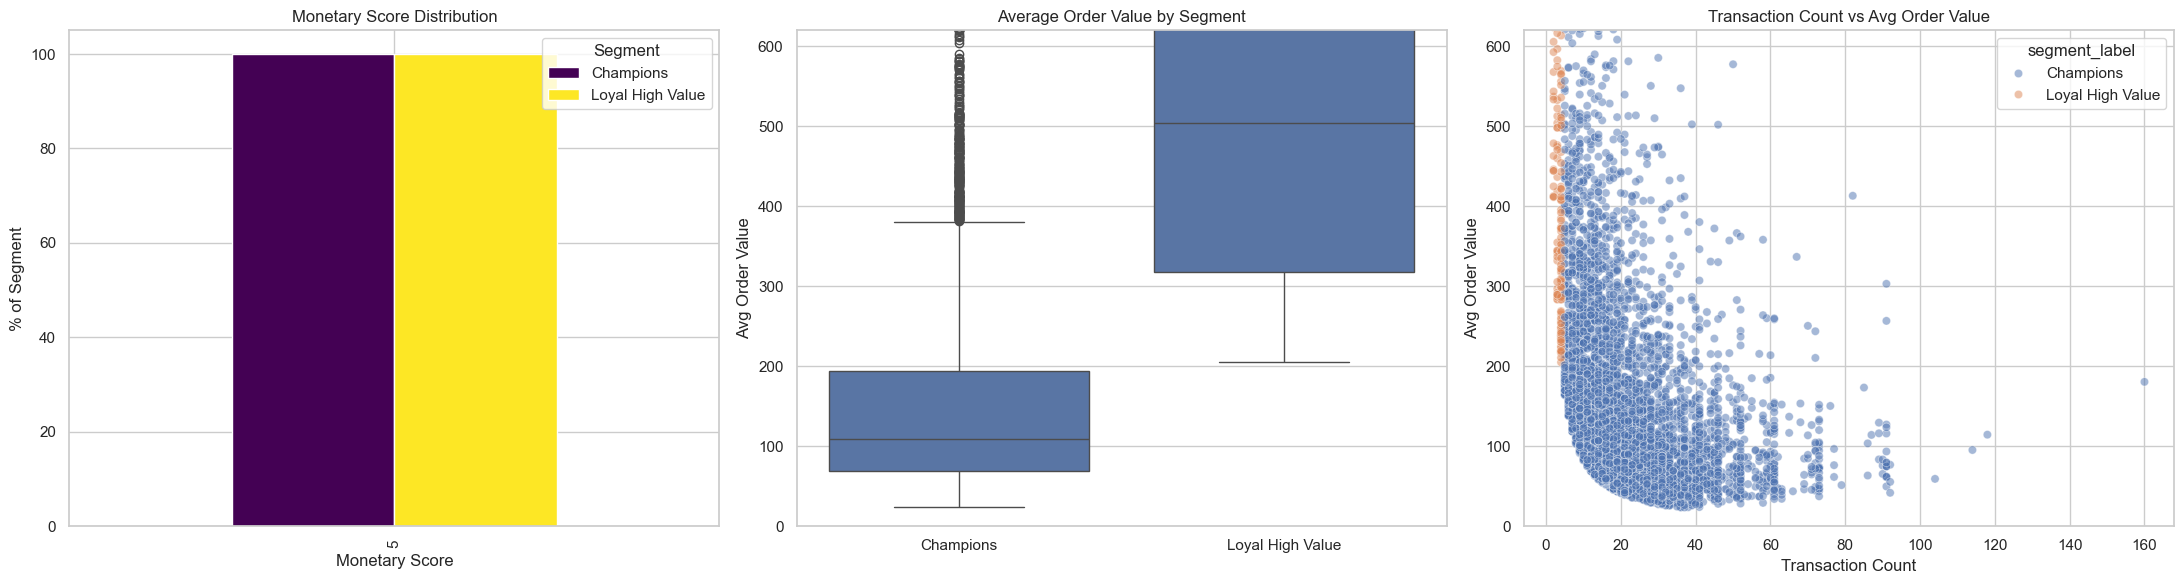

In [872]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Focus on the two segments in question
focus_segments = ["Loyal High Value", "Champions"]
focus = RFM[RFM["segment_label"].isin(focus_segments)].copy()

# Helper metric
focus["items_per_txn"] = focus["quantity"] / focus["transaction_count"]

print("1. Monetary Score Distribution Within Segment")
monetary_dist = pd.crosstab(
    focus["segment_label"],
    focus["monetary_score"],
    normalize="index"
).mul(100).round(2)

print(monetary_dist)
print()

print("2. Segment Summary")
segment_summary = focus.groupby("segment_label").agg(
    customers=("customer_id", "count"),
    avg_total_spent=("total_spent", "mean"),
    median_total_spent=("total_spent", "median"),
    avg_aov=("avg_order_value", "mean"),
    median_aov=("avg_order_value", "median"),
    avg_txn=("transaction_count", "mean"),
    median_txn=("transaction_count", "median"),
    avg_items_per_txn=("items_per_txn", "mean"),
    median_items_per_txn=("items_per_txn", "median"),
).round(2)

print(segment_summary)
print()

print("3. Loyal High Value Split By Monetary Score")
loyal_split = (
    focus[focus["segment_label"] == "Loyal High Value"]
    .groupby("monetary_score")
    .agg(
        customers=("customer_id", "count"),
        avg_total_spent=("total_spent", "mean"),
        median_total_spent=("total_spent", "median"),
        avg_aov=("avg_order_value", "mean"),
        median_aov=("avg_order_value", "median"),
        avg_txn=("transaction_count", "mean"),
        median_txn=("transaction_count", "median"),
    )
    .round(2)
    .sort_index(ascending=False)
)

loyal_split["customer_pct"] = (
    loyal_split["customers"] / loyal_split["customers"].sum() * 100
).round(2)

print(loyal_split)
print()

print("4. AOV Band Distribution (%)")
aov_bins = [0, 50, 100, 150, 200, 300, 500, 1000, float("inf")]
aov_labels = ["<=50", "50-100", "100-150", "150-200", "200-300", "300-500", "500-1000", "1000+"]

focus["aov_band"] = pd.cut(
    focus["avg_order_value"],
    bins=aov_bins,
    labels=aov_labels,
    include_lowest=True
)

aov_dist = pd.crosstab(
    focus["segment_label"],
    focus["aov_band"],
    normalize="index"
).mul(100).round(2)

print(aov_dist)
print()

# -----------------------
# Plots
# -----------------------
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot 1: monetary score mix
monetary_dist.T.plot(kind="bar", ax=axes[0], colormap="viridis")
axes[0].set_title("Monetary Score Distribution")
axes[0].set_xlabel("Monetary Score")
axes[0].set_ylabel("% of Segment")
axes[0].legend(title="Segment")

# Plot 2: AOV distributions
sns.boxplot(
    data=focus,
    x="segment_label",
    y="avg_order_value",
    ax=axes[1]
)
axes[1].set_title("Average Order Value by Segment")
axes[1].set_xlabel("")
axes[1].set_ylabel("Avg Order Value")
axes[1].set_ylim(0, focus["avg_order_value"].quantile(0.95))

# Plot 3: transaction count vs AOV
sns.scatterplot(
    data=focus,
    x="transaction_count",
    y="avg_order_value",
    hue="segment_label",
    alpha=0.5,
    ax=axes[2]
)
axes[2].set_title("Transaction Count vs Avg Order Value")
axes[2].set_xlabel("Transaction Count")
axes[2].set_ylabel("Avg Order Value")
axes[2].set_ylim(0, focus["avg_order_value"].quantile(0.95))

plt.tight_layout()
plt.show()
